# 2D/3D registration with gradient-based optimization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eigenvivek/nanodrr/blob/main/tutorials/optim.ipynb)

In [ ]:
!uv pip install "nanodrr[all]"

To perform differentiable registration with `nanodrr`, we do the following:

1. Obtain a fixed X-ray
2. Initialize a moving X-ray from a random camera pose
3. Compute the loss between the moving and fixed X-rays using cross correlation
4. Backprop the loss to the moving pose parameters
5. Repeat 3-4 until converged

In [1]:
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

## Initialization

Generate a fixed and moving image using the same pose parameters as the [demo registration notebook from `DiffDRR`](https://vivekg.dev/DiffDRR/tutorials/registration.html).

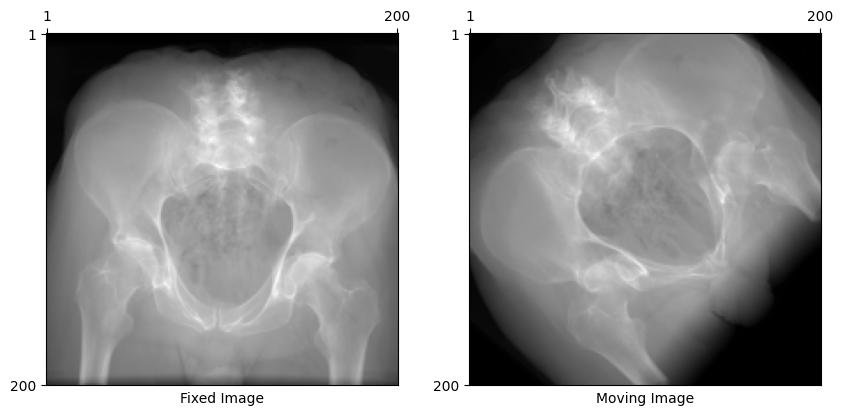

In [2]:
from nanodrr.camera import make_k_inv, make_rt_inv
from nanodrr.data import Subject, download_deepfluoro
from nanodrr.drr import render
from nanodrr.plot import plot_drr

# Load the volume
imagepath, labelpath = download_deepfluoro(subject=1)
subject = Subject.from_filepath(imagepath).to(device)

# Construct the inverse intrinsic matrix from C-arm imaging parameters
sdd = 1020.0
delx = dely = 2.0
x0 = y0 = 0.0
height = width = 200

k_inv = make_k_inv(sdd, delx, dely, x0, y0, height, width, device=device)
sdd = torch.tensor([sdd], device=device)

# Construct the ground truth and initial poses
rt_inv_true = make_rt_inv(
    rotation=torch.tensor([[0.0, 0.0, 0.0]]),
    translation=torch.tensor([[0.0, 850.0, 0.0]]),
    orientation="AP",
    isocenter=subject.isocenter.cpu(),
).to(dtype=torch.float32, device=device)

rot = torch.tensor([[-0.1303, 0.3461, -0.7852]]) / torch.pi * 180
xyz = torch.tensor([[-11.8600, 828.8053, -24.4597]])
rt_inv_pred = make_rt_inv(
    rotation=rot,
    translation=xyz,
    orientation="AP",
    isocenter=subject.isocenter.cpu(),
).to(dtype=torch.float32, device=device)

# Plot the fixed and moving images
true = render(subject, k_inv, rt_inv_true, sdd, height, width).sum(dim=1, keepdim=True)
pred = render(subject, k_inv, rt_inv_pred, sdd, height, width).sum(dim=1, keepdim=True)
plot_drr(torch.concat([true, pred]), title=["Fixed Image", "Moving Image"])
plt.show()

## Registration

We apply the Adam optimizer with different learning rates for the rotational and translational parameters.

 11%|██████████████████████▋                                                                                                                                                                                | 57/500 [00:00<00:04, 103.44it/s]


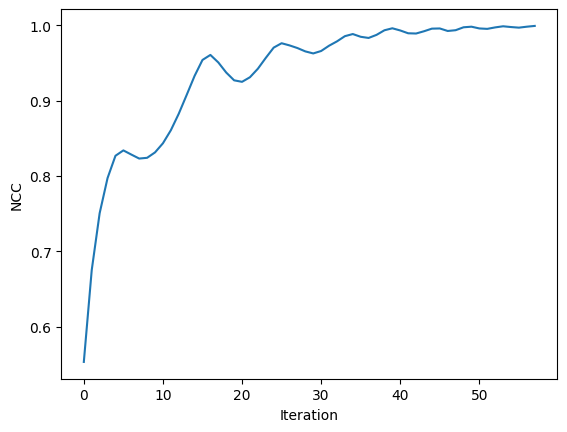

In [3]:
from nanodrr.metrics import NormalizedCrossCorrelation2d
from nanodrr.registration import Registration

# Optimization hyperparameters
LR_ROT = 5e-2
LR_XYZ = 1e1
N_ITRS = 500
CONVERGENCE = 0.999

# Registration module
reg = Registration(subject, rt_inv_pred, k_inv, sdd, height, width)
opt = torch.optim.Adam(
    [
        {"params": [reg._rot], "lr": LR_ROT},
        {"params": [reg._xyz], "lr": LR_XYZ},
    ],
    maximize=True,
)

# Loss function
ncc = NormalizedCrossCorrelation2d()

# Run the optimization loop
losses = []
poses = []
for idx in tqdm(range(N_ITRS)):
    opt.zero_grad()
    pred = reg()
    loss = ncc(true, pred)
    loss.backward()
    opt.step()

    losses.append(loss.item())
    poses.append((reg.rt_inv @ reg.pose).cpu().detach())
    if loss > CONVERGENCE:
        break

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("NCC")
plt.show()

poses = torch.concat(poses).to(device)

## Animation

`nanodrr` contains utilities to animate sequences of DRRs as GIFs.

Rendering frames: 100%|████████████████████| 58/58 [00:02<00:00, 27.26it/s]



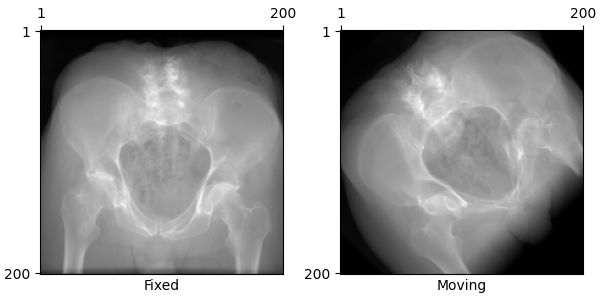

In [4]:
from nanodrr.plot import animate

moving_img = render(subject, k_inv, poses, sdd, height, width)
animate(moving_img, fixed_img=true)

## Trajectories

We can visualize the optimization trajectories with the optional `nanodrr.scene` module.

In [5]:
import pyvista as pv

from nanodrr.scene import visualize_scene
from nanodrr.scene.camera import make_cameras

pv.set_jupyter_backend("static")

2026-02-23 10:11:25.546 (   3.838s) [    7F8D360EF740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


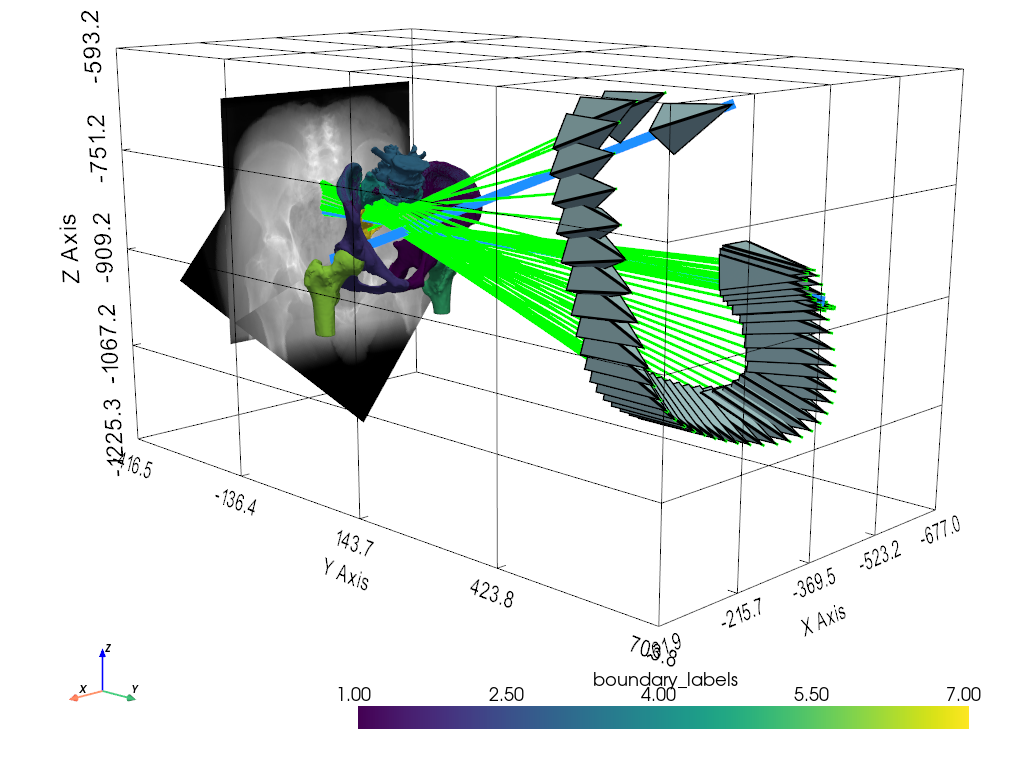

In [6]:
subject = Subject.from_filepath(imagepath, labelpath).to(device)

optends = torch.concat([rt_inv_pred, rt_inv_true])
imgs = render(subject, k_inv, optends, sdd, height, width).sum(dim=1, keepdim=True)
cameras = make_cameras(k_inv, optends, sdd, height, width, imgs)

pl = visualize_scene(subject, k_inv, poses[1:], sdd, height, width, render_imgs=False)
for cam in cameras:
    pl.add_mesh(cam["detector"], texture=cam["texture"], lighting=False, culling="back")
    pl.add_mesh(cam["camera"], show_edges=True, line_width=3, culling="back")
    pl.add_mesh(cam["principal_ray"], line_width=10, color="dodgerblue", culling="back")

pl.camera_position = "xz"
pl.camera.azimuth, pl.camera.elevation = 135, 15
pl.camera.zoom(1.25)
pl.camera.position = (pl.camera.position[0], pl.camera.position[1], pl.camera.position[2] - 175)
pl.camera.focal_point = (pl.camera.focal_point[0], pl.camera.focal_point[1], pl.camera.focal_point[2] - 175)

pl.add_axes()
pl.show_bounds(grid="front", location="outer", all_edges=True)
pl.show()